## Basic chatbot with langgraph(Graph API)

In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]


In [3]:
graph_builder=StateGraph(State)

In [4]:
graph_builder

In [5]:
import os
from dotenv import load_dotenv
load_dotenv()


True

In [6]:
os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')

In [7]:
from langchain_groq import ChatGroq

In [8]:
from langchain_groq import ChatGroq

# model=ChatGroq(model='openai/gpt-oss-20b')
model=ChatGroq(    model="openai/gpt-oss-20b"
)

In [9]:
model

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.2', 'langchain': '1.4.0'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001B5CB241ED0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001B5CB3AE110>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [10]:
def chatbot(state:State):
    return {'messages':[model.invoke(state['messages'])]}

In [11]:
graph_builder=StateGraph(State)

# Adding nodes
graph_builder.add_node('llmchatbot',chatbot)

## Adding edges
graph_builder.add_edge(START,'llmchatbot')
graph_builder.add_edge('llmchatbot', END)

## Compiling the graph
graph=graph_builder.compile()

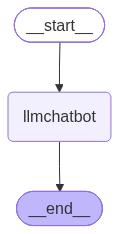

In [12]:
## Visualize the graph
from IPython.display import Image,display

try:
    
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [13]:
response=graph.invoke({'messages':[{'role':'user','content':'Hello!'}]})

In [14]:
response['messages']

[HumanMessage(content='Hello!', additional_kwargs={}, response_metadata={}, id='b739e184-26dc-4d34-9f23-19f846bf138b'),
 AIMessage(content='Hello! 👋 How can I help you today?', additional_kwargs={'reasoning_content': "We need to respond as ChatGPT. It's a greeting. Should be friendly."}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 73, 'total_tokens': 110, 'completion_time': 0.037687905, 'completion_tokens_details': {'reasoning_tokens': 17}, 'prompt_time': 0.004110416, 'prompt_tokens_details': None, 'queue_time': 0.494191263, 'total_time': 0.041798321}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_34cb00738d', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a09e47-1274-7820-b331-f68e7427aa0c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 73, 'output_tokens': 37, 'total_tokens': 110, 'output_token_details': {'reasoning': 17}})]

In [15]:
for event in graph.stream({"messages":"Hi How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

Hello! I'm just a bunch of code, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?


### Chatbot With Toolm


In [16]:
from langchain_tavily import TavilySearch
tool=TavilySearch(max_results=2)
tool.invoke('What is langgraph')

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph?',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. [...] Agent systems: LangGraph provides a framework for building agent-based systems, which can be used in applications such as robotics, autonomous vehicles or video games.\n\nLLM applications: By using LangGraph’s capabilities, developers can build more sophisticated AI models that learn and improve over time. Norwegian Cr

In [17]:
## Custom function
## Custom function
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [18]:
tools=[tool,multiply]

In [19]:
llm_with_tools=model.bind_tools(tools)

In [20]:
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.2', 'langchain': '1.4.0'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001B5CB241ED0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001B5CB3AE110>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and 

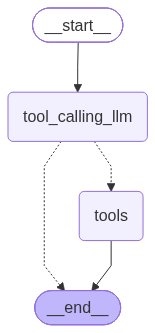

In [21]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))



In [22]:
response=graph.invoke({"messages":"What is the recent ai news"})

In [23]:
response['messages'][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://blog.google/innovation-and-ai/technology/ai/google-ai-updates-july-2026", "title": "The latest AI news we announced in July 2026 - Google Blog", "content": "# The latest AI news we announced in July 2026\\n\\nAug 04, 2026\\n\\n|\\n9 min read\\n\\n   x.com\\n   Facebook\\n   LinkedIn\\n   Mail\\n   Copy link \\n\\nHere’s a recap of some of our biggest AI updates from July, including three new Gemini models for building AI agents at scale and Gemini Robotics ER 2 to help robots reason, collaborate, and solve real-world tasks.\\n\\n  \\n\\nNews from Google Team\\n\\n Share \\n\\n   x.com\\n   Facebook\\n   LinkedIn\\n   Mail\\n   Copy link \\n\\n  \\n\\nVideo 1\\n\\nImage 2: July AI recap header\\n\\n1:45\\n\\nAudio 1\\n\\n Listen to article \\n\\n minutes\\n\\nThis content is generated by Google AI. Generative AI is experimental\\n\\nVoice Umbriel Speed 1X\\n\\nVoice Umbri

In [24]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_9b800b2f-d28b-4f97-ab4d-c69029c0b224)
 Call ID: fc_9b800b2f-d28b-4f97-ab4d-c69029c0b224
  Args:
    query: recent AI news
    search_depth: advanced
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://blog.google/innovation-and-ai/technology/ai/google-ai-updates-july-2026", "title": "The latest AI news we announced in July 2026 - Google Blog", "content": "# The latest AI news we announced in July 2026\n\nAug 04, 2026\n\n|\n9 min read\n\n   x.com\n   Facebook\n   LinkedIn\n   Mail\n   Copy link \n\nHere’s a recap of some of our biggest AI updates from July, including three new Gemini models

In [25]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()


================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (fc_f1444863-c4e5-4124-874c-dcac787eb94c)
 Call ID: fc_f1444863-c4e5-4124-874c-dcac787eb94c
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


In [26]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_5ffbed45-c762-4929-8146-fbddc11956ff)
 Call ID: fc_5ffbed45-c762-4929-8146-fbddc11956ff
  Args:
    query: recent AI news
    search_depth: advanced
    time_range: day
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.instagram.com/reel/DdOncvmNrdB", "title": "comments - Instagram", "content": "Comment “News” to get the full details.  \n  \nAI news is moving fast this week, with major updates across AI models, scientific research, AI agents, speech generation, music generation, computer vision and character animation.  \n  \nDeepSeek released V4.1 Flash,

### ReAct Agent Architecture

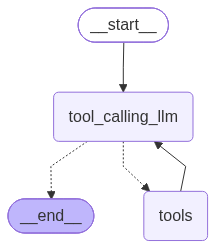

In [27]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [28]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_025cdf68-8544-4b23-8ab7-cd7ce22e674e)
 Call ID: fc_025cdf68-8544-4b23-8ab7-cd7ce22e674e
  Args:
    query: recent AI news
    search_depth: advanced
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://blog.google/innovation-and-ai/technology/ai/google-ai-updates-july-2026", "title": "The latest AI news we announced in July 2026 - Google Blog", "content": "# The latest AI news we announced in July 2026\n\nAug 04, 2026\n\n|\n9 min read\n\n   x.com\n   Facebook\n   LinkedIn\n   Mail\n   Copy link \n\nHere’s a recap of some of our biggest AI updates from July, includi

## Adding Memory In Agentic Graph

In [29]:
response=graph.invoke({"messages":"Hello my name is KRish"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is KRish
================================== Ai Message ==================================

Hello KRish! 👋 How can I help you today?


In [30]:
response=graph.invoke({"messages":"What is my name"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is my name
================================== Ai Message ==================================

I don’t have any information about your name. If you’d like to share it, feel free!


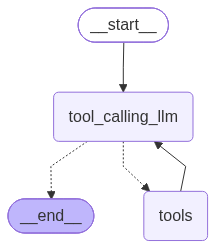

In [33]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [34]:
config={"configurable":{"thread_id":"1"}}

response=graph.invoke({"messages":"Hi my name is Dhyan"},config=config)

response



{'messages': [HumanMessage(content='Hi my name is Dhyan', additional_kwargs={}, response_metadata={}, id='90563d02-1e1c-439a-a769-6a840937e4b8'),
  AIMessage(content='Hello Dhyan! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'The user says: "Hi my name is Dhyan". They greet. We should respond warmly. No question. Probably just a friendly reply.'}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 348, 'total_tokens': 400, 'completion_time': 0.059759352, 'completion_tokens_details': {'reasoning_tokens': 30}, 'prompt_time': 0.022334008, 'prompt_tokens_details': None, 'queue_time': 0.30597512, 'total_time': 0.08209336}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_4f7e7dc26e', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a09e5a-c228-7b80-ac6e-08fcaf8b2e89-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 348, 'output_tokens': 52, 

In [35]:
response['messages'][-1].content

'Hello Dhyan! 👋 How can I help you today?'

In [36]:
response=graph.invoke({"messages":"Hey what is my name"},config=config)

print(response['messages'][-1].content)

Your name is Dhyan.


In [37]:
response=graph.invoke({"messages":"Hey do you remember mmy name"},config=config)

print(response['messages'][-1].content)

Yes, I remember—your name is Dhyan. If you’d like to share anything else or ask a question, just let me know!


### Streaming

In [40]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

In [42]:
def superbot(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

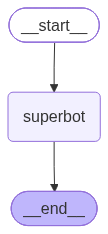

In [43]:
graph=StateGraph(State)
graph.add_node("superbot",superbot)
graph.add_edge(START,"superbot")
graph.add_edge("superbot",END)
graph=graph.compile(checkpointer=memory)
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [46]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph.invoke({'messages':"Hi,My name is Dhyan And I like cricket"},config)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='7287d651-5306-49f8-a537-5a5238fd65e5'),
  AIMessage(content="Hello Krish! It's great to meet you. Cricket is such an exciting sport—do you have a favorite team or player?", additional_kwargs={'reasoning_content': 'The user says: "Hi, My name is Krish And I like cricket". The user likely wants a friendly response. No request for action. So just respond politely.'}, response_metadata={'token_usage': {'completion_tokens': 71, 'prompt_tokens': 353, 'total_tokens': 424, 'completion_time': 0.072471878, 'completion_tokens_details': {'reasoning_tokens': 36}, 'prompt_time': 0.052622054, 'prompt_tokens_details': {'cached_tokens': 256}, 'queue_time': 0.308926685, 'total_time': 0.125093932}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_37c9245f64', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--

### Streaming 
Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.

In [49]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph.stream({'messages':"Hi,My name is Dhyan And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'superbot': {'messages': [AIMessage(content='Hello Dhyan! Nice to meet you. Cricket is a fantastic sport—do you have a favorite team or player?', additional_kwargs={'reasoning_content': 'User says "Hi,My name is Dhyan And I like cricket". They want to greet. Just respond.'}, response_metadata={'token_usage': {'completion_tokens': 57, 'prompt_tokens': 399, 'total_tokens': 456, 'completion_time': 0.060065887, 'completion_tokens_details': {'reasoning_tokens': 24}, 'prompt_time': 0.022924959, 'prompt_tokens_details': None, 'queue_time': 0.394776218, 'total_time': 0.082990846}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_8b41efc9a3', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a09e61-c00c-7401-b3af-9f30236d8607-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 399, 'output_tokens': 57, 'total_tokens': 456, 'output_token_details': {'reasoning': 24}})]}}


In [50]:
for chunk in graph.stream({'messages':"Hi,My name is Dhyan And I like cricket"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='762b7bf1-4f6b-4396-a432-6c0a7dd4e142'), AIMessage(content='Hello Krish! Great to meet you. Cricket is such an exciting sport—do you have a favorite team or player?', additional_kwargs={'reasoning_content': 'The user says: "Hi,My name is Krish And I like cricket". It\'s a greeting. We should respond politely, maybe ask about cricket. No tool needed.'}, response_metadata={'token_usage': {'completion_tokens': 70, 'prompt_tokens': 353, 'total_tokens': 423, 'completion_time': 0.086539945, 'completion_tokens_details': {'reasoning_tokens': 36}, 'prompt_time': 0.022419553, 'prompt_tokens_details': None, 'queue_time': 0.337515994, 'total_time': 0.108959498}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_587d0d67cc', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a09e61-a222-7f22-aee1-e4e3e70

In [51]:
# Create a thread
config = {"configurable": {"thread_id": "4"}}

for chunk in graph.stream({'messages':"Hi,My name is Dhyan And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'superbot': {'messages': [AIMessage(content='Hi Dhyan! 👋 It’s great to meet a cricket fan. What’s your favorite team or player? If you have any cricket questions or just want to chat about the latest matches, feel free to let me know!', additional_kwargs={'reasoning_content': 'The user says: "Hi,My name is Dhyan And I like cricket". They just introduced themselves. Probably want a friendly reply. There\'s no question. We should respond politely.'}, response_metadata={'token_usage': {'completion_tokens': 93, 'prompt_tokens': 353, 'total_tokens': 446, 'completion_time': 0.095064314, 'completion_tokens_details': {'reasoning_tokens': 38}, 'prompt_time': 0.018480775, 'prompt_tokens_details': None, 'queue_time': 0.314508894, 'total_time': 0.113545089}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_9b8528b477', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a09e63-9f8a-7a01-bfb3-5c230844fdb7-0', tool_calls=[], 

In [52]:
for chunk in graph.stream({'messages':"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Dhyan And I like cricket', additional_kwargs={}, response_metadata={}, id='7ff14c4f-db7c-40c7-b952-c21d14cc7659'), AIMessage(content='Hi Dhyan! 👋 It’s great to meet a cricket fan. What’s your favorite team or player? If you have any cricket questions or just want to chat about the latest matches, feel free to let me know!', additional_kwargs={'reasoning_content': 'The user says: "Hi,My name is Dhyan And I like cricket". They just introduced themselves. Probably want a friendly reply. There\'s no question. We should respond politely.'}, response_metadata={'token_usage': {'completion_tokens': 93, 'prompt_tokens': 353, 'total_tokens': 446, 'completion_time': 0.095064314, 'completion_tokens_details': {'reasoning_tokens': 38}, 'prompt_time': 0.018480775, 'prompt_tokens_details': None, 'queue_time': 0.314508894, 'total_time': 0.113545089}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_9b8528b477', 'service_tier': 'on_demand', 

In [53]:
config = {"configurable": {"thread_id": "5"}}


async for event in graph.astream_events({"messages":["Hi My name is Krish and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Krish and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '01a09e64-4dd1-74e1-8340-cbac755f148b', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Krish and I like to play cricket', additional_kwargs={}, response_metadata={}, id='f1f56110-00b7-49d9-853a-70f9d7f4b125')]}}, 'name': 'superbot', 'tags': ['graph:step:1'], 'run_id': '01a09e64-4dda-7a50-855d-ff49ea2cefbb', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'superbot', 'langgraph_triggers': ('branch:to:superbot',), 'langgraph_path': ('__pregel_pull', 'superbot'), 'langgraph_checkpoint_ns': 'superbot:c32514b2-9394-33fb-6dc1-e6043d79dd71'}, 'parent_ids': ['01a09e64-4dd1-74e1-8340-cbac755f148b']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages':